# Лабораторная работа: Генеративные модели классификации (LDA и Naive Bayes)

## Общая цель работы
Изучить генеративный подход к классификации на примере двух моделей: **Линейный дискриминантный анализ (LDA)** и **Наивный байесовский классификатор (NB)**. Вы не просто реализуете алгоритмы, а исследуете, как предположения о структуре данных (ковариация, независимость признаков) влияют на разделяющую поверхность и качество классификации.

---

## Теоретическое введение (обязательно к прочтению)

### Генеративный vs дискриминативный подход
- **Дискриминативные модели** (логистическая регрессия, SVM) моделируют границу между классами напрямую: $ p(y|x) $.
- **Генеративные модели** моделируют совместное распределение $ p(x, y) = p(x|y) \cdot p(y) $, а затем через теорему Байеса получают $ p(y|x) $.

### Байесовский классификатор
Для задачи классификации с $ K $ классами:
$
\hat{y} = \arg\max_{y} p(y|x) = \arg\max_{y} \frac{p(x|y) \cdot p(y)}{p(x)} = \arg\max_{y} p(x|y) \cdot p(y)
$

Где:
- $ p(y) $ — **априорная вероятность** класса (оценивается как доля объектов класса в выборке).
- $ p(x|y) $ — **правдоподобие** (likelihood) — вероятность наблюдать объект $ x $ в классе $ y $.

### Два подхода к моделированию правдоподобия

**1. LDA (Линейный дискриминантный анализ)**
- Предполагает, что $ p(x|y) $ — многомерное нормальное распределение.
- **Ключевое допущение:** матрицы ковариации для всех классов **одинаковы**: $ C_0 = C_1 = ... = C $.
- **Следствие:** разделяющая поверхность между классами является **линейной** (гиперплоскостью).
- Параметры для каждого класса: $ \mu_y $ (среднее) и общая $ C $.

**2. Наивный байесовский классификатор (NB)**
- Также предполагает нормальное распределение $ p(x|y) $, но **без учета корреляций** между признаками.
- **Ключевое допущение:** признаки условно независимы при заданном классе:
  $
  p(x_1, x_2, ..., x_n|y) = \prod_{i=1}^{n} p(x_i|y)
  $
- **Следствие:** матрица ковариации для каждого класса **диагональная** (все внедиагональные элементы = 0).
- Параметры для каждого класса: $ \mu_y $ и $ \sigma_{y,i}^2 $ (дисперсия каждого признака отдельно).

**Важно:** LDA и NB — частные случаи одного и того же байесовского подхода, различающиеся структурой ковариационной матрицы:
- LDA: одна полная матрица ковариации $ C $ для всех классов.
- NB: отдельная диагональная матрица для каждого класса.

---

## Часть 1. Исследование многомерного нормального распределения (10 баллов)

### 1.1 Генерация данных с заданной ковариацией
**Цель:** научиться генерировать данные с контролируемой структурой зависимости.

1. Создайте $ M = 500 $ точек в двумерном пространстве:
   - Сгенерируйте два независимых вектора: $ x_1 \sim \mathcal{N}(0, \sigma_1^2) $, $ x_2 \sim \mathcal{N}(0, \sigma_2^2) $, где $ \sigma_1 = 0.3 $, $ \sigma_2 = 0.8 $.
2. Примените матрицу поворота на угол $ \alpha = 30^\circ $:
   $
   R = \begin{bmatrix} \cos\alpha & -\sin\alpha \\ \sin\alpha & \cos\alpha \end{bmatrix}
   $
3. Выведите на экран **выборочную матрицу ковариации** (через `np.cov`).
4. Сравните с теоретической: $ C_{теор} = R \cdot \text{diag}(\sigma_1^2, \sigma_2^2) \cdot R^T $.

**Визуализация:**
- Постройте scatter plot полученных точек.
- На том же графике (используя `plt.contour`) нарисуйте эллипсы равной плотности для теоретического распределения (на уровнях 0.5, 1, 2 стандартных отклонения).

**Автопроверка:**
```python
# Проверка: размерность и наличие поворота
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
```

### 1.2 Сравнение с встроенной функцией
- Сгенерируйте точки с помощью `np.random.multivariate_normal` с той же матрицей ковариации.
- Нарисуйте оба облака точек на одном графике разными цветами.
- **Вопрос (ответить текстом в Markdown):** совпадают ли облака визуально? Почему встроенная функция может быть предпочтительнее?

---

## Часть 2. Визуализация плотности вероятности (5 баллов)

**Цель:** научиться вычислять и визуализировать PDF многомерного нормального распределения.

1. По данным из пункта 1.1 оцените $ \hat{\mu} $ и $ \hat{C} $ (выборочные).
2. Создайте сетку точек в диапазоне от -2 до 2 по обеим осям.
3. Вычислите плотность вероятности в каждой точке сетки **двумя способами**:
   - С помощью `scipy.stats.multivariate_normal(mean=mu, cov=C).pdf()`.
   - Самостоятельно по формуле (1) из задания (используйте `np.linalg.det` и `np.linalg.inv`).
4. Сравните результаты (максимальная разница должна быть < 1e-10).

**Визуализация:**
- Постройте contour plot с заливкой (используя `plt.contourf`).
- Добавьте линии уровня (contour) с подписями значений.
- Нанесите исходные точки поверх фона.

**Автопроверка:**
```python
# Проверка ручного вычисления
pdf_manual = ... # ваша реализация
pdf_scipy = m.pdf(grid_points)
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"
```

---

## Часть 3. Бинарная классификация через байесовский подход (15 баллов)

**Цель:** визуализировать разделяющую поверхность для двух классов.

### 3.1 Генерация датасета
Создайте два класса (по 300 точек каждый):
- **Класс 0:** $ \mu_0 = (-0.5, 0.5) $, $ C_0 = \begin{bmatrix} 0.2 & 0.1 \\ 0.1 & 0.3 \end{bmatrix} $
- **Класс 1:** $ \mu_1 = (0.5, -0.5) $, $ C_1 = \begin{bmatrix} 0.3 & -0.1 \\ -0.1 & 0.2 \end{bmatrix} $

### 3.2 Визуализация апостериорной вероятности
Для каждой точки сетки вычислите:
$
\Delta(x) = p(x|y=0) \cdot p(y=0) - p(x|y=1) \cdot p(y=1)
$
где $ p(y) $ оценивается как доля объектов класса в выборке.

**Визуализация:**
- Scatter plot точек классов (разными цветами).
- Заливка фона: положительные значения $ \Delta $ — одним цветом (например, синим), отрицательные — другим (красным).
- Линия, где $ \Delta(x) = 0 $ (разделяющая поверхность) — через `plt.contour(..., levels=[0])`.

**Вопрос (ответить текстом):** является ли разделяющая поверхность линейной? Почему?

---

## Часть 4. Линейный дискриминантный анализ (LDA) (20 баллов)

### 4.1 Теоретический вывод (в тетради)
**Задание:** выведите явное выражение для разделяющей поверхности в случае, когда $ C_0 = C_1 = C $. Покажите, что она линейна. Напишите формулу для весов $ w $ и порога $ b $ в уравнении $ w^T x + b = 0 $.

### 4.2 Реализация класса LDA
Реализуйте класс `MyLDA`, следуя шаблону:

```python
from sklearn.base import BaseEstimator
import numpy as np

class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # словарь {class: mean_vector}
        self.priors_ = None     # словарь {class: prior_prob}
        self.cov_ = None        # общая ковариационная матрица (2D массив)
        self.coef_ = None       # вектор весов w
        self.intercept_ = None  # порог b
    
    def fit(self, X, y):
        """
        X: np.array, shape (n_samples, n_features)
        y: np.array, shape (n_samples,)
        """
        # 1. Сохранить уникальные классы
        # 2. Для каждого класса: вычислить mean и prior
        # 3. Вычислить общую ковариационную матрицу (усредненную по классам)
        # 4. Вычислить w и b
        pass
    
    def predict(self, X):
        """Возвращает предсказанные классы для X"""
        pass
    
    def predict_proba(self, X):
        """Возвращает вероятности принадлежности к каждому классу"""
        pass
```

**Указания:**
- Для устойчивости добавьте небольшой регуляризатор к ковариационной матрице: `cov_reg = cov + 1e-6 * np.eye(n_features)`.
- Формула для весов для бинарного случая:
  $
  w = C^{-1} (\mu_1 - \mu_0)
  $
  $
  b = -\frac{1}{2} \mu_0^T C^{-1} \mu_0 + \frac{1}{2} \mu_1^T C^{-1} \mu_1 + \log\frac{p(y=1)}{p(y=0)}
  $

### 4.3 Проверка на синтетике
- Создайте два класса с одинаковой ковариацией $ C = \begin{bmatrix} 1 & 0.5 \\ 0.5 & 1 \end{bmatrix} $, но разными средними.
- Обучите ваш `MyLDA` и сравните предсказания с `sklearn.discriminant_analysis.LinearDiscriminantAnalysis`.
- Визуализируйте разделяющую прямую и точки.

**Автопроверка:**
```python
# Сравнение с sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
my_lda = MyLDA().fit(X_train, y_train)
assert np.allclose(my_lda.predict(X_test), sk_lda.predict(X_test)), "Предсказания не совпадают"
assert np.abs(my_lda.coef_ @ sk_lda.coef_ - 1) < 1e-6, "Вектора весов сонаправлены, но разной длины"
```

---

## Часть 5. Наивный байесовский классификатор (NB) (20 баллов)

### 5.1 Теоретическое обоснование
**Вопрос:** почему в наивном байесе матрица ковариации диагональная? Как это упрощает вычисление $ p(x|y) $?

### 5.2 Реализация класса NB
Реализуйте класс `MyNB`:

```python
class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # dict {class: mean_vector}
        self.vars_ = None       # dict {class: variance_vector} (диагональ ковариации)
        self.priors_ = None     # dict {class: prior_prob}
    
    def fit(self, X, y):
        """
        Для каждого класса:
        - Вычислить среднее по каждому признаку
        - Вычислить дисперсию по каждому признаку
        - Вычислить априорную вероятность
        """
        pass
    
    def predict(self, X):
        """Вычисляет логарифм правдоподобия для каждого класса и выбирает максимум"""
        pass
```

**Важно:** используйте **логарифмическое правдоподобие** для численной устойчивости:
$
\log p(y|x) \propto \log p(y) + \sum_i \log p(x_i|y) = \log p(y) - \frac{1}{2}\sum_i \left( \log(2\pi\sigma_{y,i}^2) + \frac{(x_i - \mu_{y,i})^2}{\sigma_{y,i}^2} \right)
$

### 5.3 Сравнение с sklearn
- Сравните ваш `MyNB` с `sklearn.naive_bayes.GaussianNB` на тех же данных.
- Убедитесь, что предсказания совпадают (с точностью до численных погрешностей).

**Автопроверка:**
```python
from sklearn.naive_bayes import GaussianNB
sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)
assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), "Предсказания NB не совпадают"
```

---

## Часть 6. Экспериментальное сравнение LDA и NB (15 баллов)

### 6.1 Генерация датасетов с разной структурой
Создайте **три** различных датасета для бинарной классификации:

1. **Датасет A (LDA-оптимальный):** классы имеют одинаковую ковариацию, но разные средние.
2. **Датасет B (NB-оптимальный):** признаки независимы внутри каждого класса, но ковариации классов разные.
3. **Датасет C (сложный):** признаки коррелированы, ковариации классов разные.

Используйте `sklearn.datasets.make_classification` с параметрами:
- `n_features=10` (для проверки многомерности)
- `n_informative=5`, `n_redundant=2`
- Для датасета C: `flip_y=0.05` (немного шума).

### 6.2 Сравнение моделей
Для каждого датасета:
1. Разделите на train/test (80/20).
2. Обучите `MyLDA`, `MyNB`, а также (для бенчмарка) `sklearn.linear_model.LogisticRegression`.
3. Посчитайте метрики: **Accuracy**, **Precision**, **Recall**, **F1-score** (для каждого класса отдельно и macro-усредненные).
4. Постройте confusion matrix для каждой модели.

### 6.3 Анализ результатов
В Markdown-ячейке напишите **развернутый вывод**:
- На каком датасете LDA превосходит NB? Почему?
- На каком датасете NB работает лучше? Почему?
- Как влияет размерность пространства на обе модели?
- Когда обе модели падают (датасет C) — почему?

**Визуализация:** для каждого датасета постройте столбчатую диаграмму сравнения метрик.

---

## Критерии оценки (максимум 85 баллов)

| Часть | Баллы | Что проверяется |
|-------|-------|-----------------|
| 1.1 Генерация и поворот | 5 | Корректная генерация, визуализация, сравнение ковариаций |
| 1.2 Сравнение с `multivariate_normal` | 5 | Понимание способов генерации |
| 2. PDF и визуализация | 5 | Ручное вычисление, сравнение со scipy |
| 3. Бинарная классификация | 10 | Правильная визуализация Δ и разделяющей поверхности |
| 4.1 Теоретический вывод LDA | 5 | Формулы для w и b |
| 4.2 Реализация MyLDA | 10 | Код, совместимость со sklearn API |
| 4.3 Проверка на синтетике | 5 | Сравнение с sklearn, визуализация |
| 5.1 Теория NB | 5 | Понимание условной независимости |
| 5.2 Реализация MyNB | 10 | Код, логарифмическое правдоподобие |
| 5.3 Проверка с sklearn | 5 | Совпадение предсказаний |
| 6.1 Генерация 3 датасетов | 5 | Разнообразие структур |
| 6.2 Эксперименты и метрики | 10 | Все метрики, confusion matrix |
| 6.3 Анализ и выводы | 10 | Глубокий анализ результатов |
| **Стиль кода и оформление** | **Бонус +5** | Чистый код, комментарии, структура ноутбука |

---

## Полезные функции и материалы

### Генерация датасета с заданной ковариацией
```python
def generate_gaussian_class(mean, cov, n_samples=300):
    return np.random.multivariate_normal(mean, cov, n_samples)

# Пример создания двух классов
X0 = generate_gaussian_class(mean0, cov0, 300)
X1 = generate_gaussian_class(mean1, cov1, 300)
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(300), np.ones(300)])
```

### Вычисление разделяющей поверхности
```python
def decision_function(X, means, cov, priors):
    """Возвращает разность логарифмов апостериорных вероятностей"""
    log_p0 = np.log(priors[0]) + multivariate_normal(means[0], cov).logpdf(X)
    log_p1 = np.log(priors[1]) + multivariate_normal(means[1], cov).logpdf(X)
    return log_p1 - log_p0  # >0 => класс 1, <0 => класс 0
```

---

## Рекомендации по оформлению

1. Каждая часть должна быть отдельным разделом с заголовком.
2. Код должен быть прокомментирован (на русском или английском).
3. Все графики должны иметь подписи осей и легенды.
4. В конце каждой части — краткий вывод (1-2 предложения).
5. Итоговый вывод — развернутый (10+ предложений) с ответами на все поставленные вопросы.

---

Это задание теперь требует не только написания кода, но и **понимания теории** через визуализацию и эксперименты. Все блоки с проверками помогут студентам самостоятельно убедиться в корректности решения, а преподавателю — быстро оценить работу.

# Часть 1


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

In [3]:
M = 500
sigma1, sigma2 = 0.3, 0.8
np.random.seed(42)

X_uncorr = np.random.randn(M, 2) * np.array([sigma1, sigma2])

In [4]:
alpha_deg = 30
alpha_rad = np.radians(alpha_deg)
R = np.array([
    [np.cos(alpha_rad), -np.sin(alpha_rad)],
    [np.sin(alpha_rad),  np.cos(alpha_rad)]
])

X = X_uncorr @ R.T


In [5]:

sample_cov = np.cov(X.T)

In [7]:
D = np.diag([sigma1**2, sigma2**2])
theor_cov = R @ D @ R.T

print(sample_cov)
print(theor_cov)

[[ 0.22582011 -0.23928472]
 [-0.23928472  0.48810235]]
[[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]


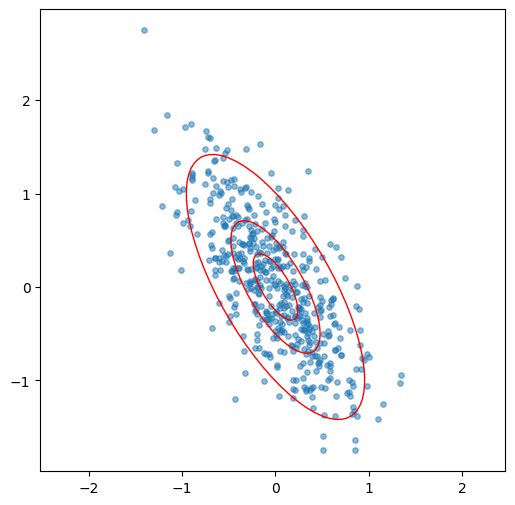

In [13]:
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, s=15)

for c in [0.5, 1, 2]:
    ellipse = Ellipse(xy=(0, 0),
                      width=2 * c * sigma1,
                      height=2 * c * sigma2,
                      angle=alpha_deg,
                      edgecolor='red',
                      facecolor='none')
    plt.gca().add_patch(ellipse)

plt.axis('equal')
plt.show()

In [14]:
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
print("Все проверки пройдены успешно!")

Все проверки пройдены успешно!


нет, визуально облака почти совпадают, но не идентичны, потому что это две разные случайные выборки из одного распределения.

встроенная функция лучше, потому что она короче, не требует ручного построения матрицы поворота и сразу принимает матрицу ковариации, что удобнее и меньше шансов ошибиться.



# Часть 2

![2](mHxVjcrBXanagL7VVVJV-RSX_ZshBEZKQKByYmrwmObvk_IhwYpX4Hql8GPdvhi_abVvHwjgxqYz5c8hElZBkbRS.jpg)

![2](SKnKS5U0x_vCKW9sMPOArUR9wXHzmCfEtrddzgk5iRn5VFyMUx8mptYWNu8_PeZUxc1coBhfHjBxvBXs24YDM5WY.jpg)

In [19]:
from scipy.stats import multivariate_normal

In [20]:
mu = np.mean(X, axis=0)
C = np.cov(X.T)

In [21]:
x_vals = np.linspace(-2, 2, 100)
y_vals = np.linspace(-2, 2, 100)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)
grid_points = np.dstack((X_grid, Y_grid))

In [22]:
m = multivariate_normal(mean=mu, cov=C)
pdf_scipy = m.pdf(grid_points)

#### формула выше

In [25]:
d = 2
det_C = np.linalg.det(C)
inv_C = np.linalg.inv(C)
norm_const = 1.0 / ((2 * np.pi)**(d/2) * np.sqrt(det_C))

pdf_manual = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        diff = np.array([x_vals[j], y_vals[i]]) - mu
        exponent = -0.5 * diff.T @ inv_C @ diff
        pdf_manual[i, j] = norm_const * np.exp(exponent)

In [26]:
max_diff = np.max(np.abs(pdf_manual - pdf_scipy))
print("Максимальная разница:", max_diff)
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-10), "Ручное вычисление отличается от scipy"
print("Проверка пройдена!")

Максимальная разница: 2.7755575615628914e-16
Проверка пройдена!


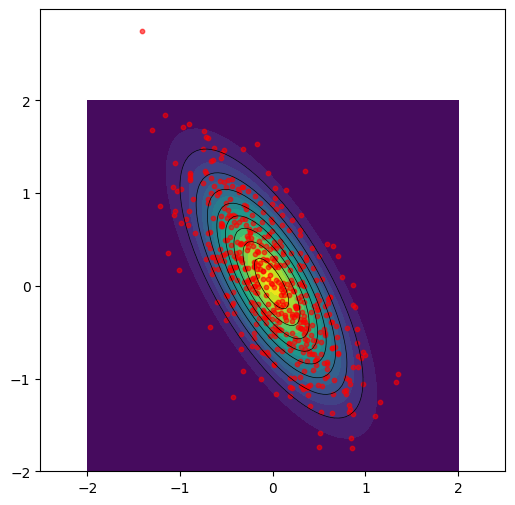

In [28]:

plt.figure(figsize=(6, 6))
plt.contourf(X_grid, Y_grid, pdf_manual, levels=20, cmap='viridis')
plt.contour(X_grid, Y_grid, pdf_manual, levels=10, colors='black', linewidths=0.5)
plt.scatter(X[:, 0], X[:, 1], c='red', s=10, alpha=0.6)
plt.axis('equal')
plt.show()

визуализировала плотность: темнее - там плотность выше

# Часть 3

![3](qBhCTQ2Z7PjvpEXt72Ek8LHtFuK7-vzqfyKgBJ9drnuDsCHNDJqcXXEPROhH6ZuYALpEIYfbnf2uaLKR9g2RJC-Y.jpg)

In [29]:
N = 300

In [30]:
mu0 = np.array([-0.5, 0.5])
C0 = np.array([[0.2, 0.1],
               [0.1, 0.3]])

mu1 = np.array([0.5, -0.5])
C1 = np.array([[0.3, -0.1],
               [-0.1, 0.2]])

np.random.seed(42)


In [31]:
X0 = np.random.multivariate_normal(mu0, C0, N)
X1 = np.random.multivariate_normal(mu1, C1, N) 

In [32]:
X_all = np.vstack([X0, X1])
y_all = np.hstack([np.zeros(N), np.ones(N)]) 

In [34]:
p0 = np.mean(y_all == 0)
p1 = np.mean(y_all == 1) 
print(f"p(0) = {p0}, p(1) = {p1}")

p(0) = 0.5, p(1) = 0.5


In [35]:
x_vals = np.linspace(-3, 3, 200)
y_vals = np.linspace(-3, 3, 200)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)
grid_points = np.dstack((X_grid, Y_grid)).reshape(-1, 2)

In [36]:
pdf0 = multivariate_normal(mean=mu0, cov=C0).pdf(grid_points)
pdf1 = multivariate_normal(mean=mu1, cov=C1).pdf(grid_points)

In [37]:
delta = (pdf0 * p0 - pdf1 * p1).reshape(200, 200)

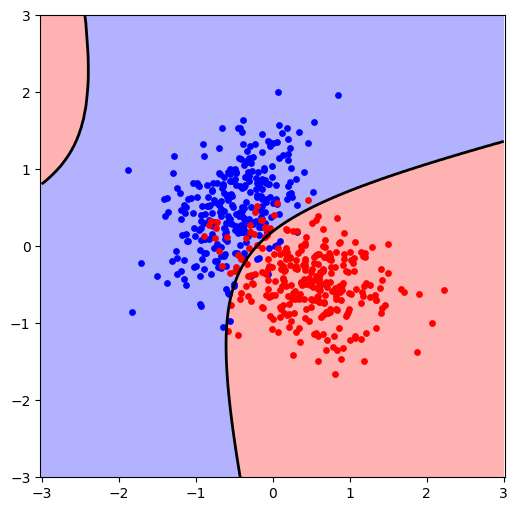

In [39]:
plt.figure(figsize=(6, 6))

plt.contourf(X_grid, Y_grid, delta, levels=[delta.min(), 0, delta.max()],
             colors=['red', 'blue'], alpha=0.3)

plt.contour(X_grid, Y_grid, delta, levels=[0], colors='black', linewidths=2)

plt.scatter(X0[:, 0], X0[:, 1], c='blue', s=15)
plt.scatter(X1[:, 0], X1[:, 1], c='red', s=15)

plt.axis('equal')
plt.show()

### разделяющая поверхность не линейна

##### в начале для двух нормальных классов граница обычно кривая (эллипс). у нас матрицы ковариации C0 и C1 разные.

# Часть 4

![4.1](4a1.jpg)

In [79]:
# аналог LinearDiscriminantAnalysis из sklearn

In [50]:
class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None
        self.priors_ = None
        self.cov_ = None
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.means_ = {}
        self.priors_ = {}
        for c in self.classes_:
            X_c = X[y == c]
            self.means_[c] = X_c.mean(axis=0)
            self.priors_[c] = len(X_c) / len(X)

        n_feat = X.shape[1]
        cov = np.zeros((n_feat, n_feat))
        for c in self.classes_:
            X_c = X[y == c]
            diff = X_c - self.means_[c]
            cov += diff.T @ diff
        cov = cov / len(X) + 1e-6 * np.eye(n_feat)
        self.cov_ = cov

        mu0 = self.means_[0]
        mu1 = self.means_[1]
        inv_cov = np.linalg.inv(cov)
        self.coef_ = inv_cov @ (mu1 - mu0)
        self.intercept_ = (
            -0.5 * mu0 @ inv_cov @ mu0
            + 0.5 * mu1 @ inv_cov @ mu1
            + np.log(self.priors_[1] / self.priors_[0])
        )
        return self

    def predict(self, X):
        return (X @ self.coef_ + self.intercept_ > 0).astype(int)

    def predict_proba(self, X):
        score = X @ self.coef_ + self.intercept_
        p1 = 1 / (1 + np.exp(-score))
        return np.column_stack([1 - p1, p1])

Все проверки пройдены!


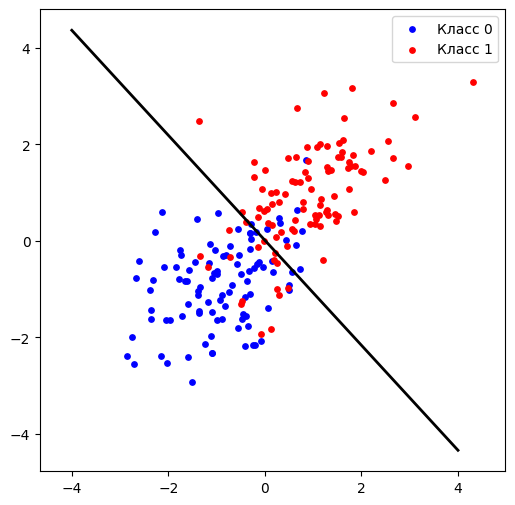

In [59]:
np.random.seed(42)
C = np.array([[1, 0.5],
              [0.5, 1]])

X0 = np.random.multivariate_normal([-1, -1], C, 100)
X1 = np.random.multivariate_normal([ 1,  1], C, 100)

X = np.vstack([X0, X1])
y = np.hstack([np.zeros(100), np.ones(100)])

my = MyLDA().fit(X, y)
sk = LinearDiscriminantAnalysis().fit(X, y)

# print("my.coef_ shape:", my.coef_.shape)
# print("sk.coef_ shape:", sk.coef_.shape)

w1 = my.coef_ / np.linalg.norm(my.coef_)
w2 = sk.coef_.ravel() / np.linalg.norm(sk.coef_.ravel())

assert np.allclose(my.predict(X), sk.predict(X)), "Предсказания не совпадают"
assert np.abs(np.abs(w1 @ w2) - 1) < 1e-6, "Веса не сонаправлены"
print("Все проверки пройдены!")

plt.figure(figsize=(6, 6))
plt.scatter(X0[:, 0], X0[:, 1], c='blue', s=15, label='Класс 0')
plt.scatter(X1[:, 0], X1[:, 1], c='red',  s=15, label='Класс 1')

x1_line = np.linspace(-4, 4, 100)
x2_line = -(my.coef_[0] * x1_line + my.intercept_) / my.coef_[1]
plt.plot(x1_line, x2_line, 'k-', linewidth=2)

plt.legend()
plt.axis('equal')
plt.show()

# Часть 5

![5.1](r_ImMKXUQjTb2yLFjSXmDbyqQyfIO8qff9tQII1aBP-QIapKxA9H2iDMbuZM8tIHqpAs75U6gpwxrxJrTa4NAVoe.jpg)

In [ ]:
# аналог GaussianNB

# отличие от LDA - признаки считаются независимыми внутри класса, поэтому ковариация диагональная.

![5](aA98hUm92rOKSiTbEReUMseiaq85KKhHtoItAgpqgZy7ou6hoTsnWCLj0vMjeiBfGYEYfLIFNjDDLNb3rhIVhpK9.jpg)

In [82]:
class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None
        self.vars_ = None
        self.priors_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.means_ = {}
        self.vars_ = {}
        self.priors_ = {}
        for c in self.classes_:
            X_c = X[y == c]
            self.means_[c] = X_c.mean(axis=0)
            self.vars_[c] = X_c.var(axis=0)
            self.priors_[c] = len(X_c) / len(X)
        return self

    def predict(self, X):
        log_probs = []
        for c in self.classes_:
            mu = self.means_[c]
            var = self.vars_[c]
            prior = self.priors_[c]
            log_likelihood = np.log(prior) - 0.5 * np.sum(
                np.log(2 * np.pi * var) + (X - mu)**2 / var,
                axis=1
            )
            log_probs.append(log_likelihood)
        log_probs = np.array(log_probs)
        return self.classes_[np.argmax(log_probs, axis=0)]

In [61]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)

assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), "Предсказания NB не совпадают"
print("Все проверки пройдены!")

Все проверки пройдены!


# Часть 6

In [72]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [73]:
X_A, y_A = make_classification(
    n_samples=500, n_features=10, n_informative=5, n_redundant=2,
    n_classes=2, random_state=42
)

In [74]:
X_B, y_B = make_classification(
    n_samples=500, n_features=10, n_informative=5, n_redundant=2,
    n_classes=2, flip_y=0.05, random_state=42
)


In [75]:
X_C, y_C = make_classification(
    n_samples=500, n_features=10, n_informative=5, n_redundant=2,
    n_classes=2, flip_y=0.05, class_sep=0.5, random_state=42
)


In [76]:
datasets = {
    'A (LDA-opt)': (X_A, y_A),
    'B (NB-opt)':  (X_B, y_B),
    'C (сложный)': (X_C, y_C),
}

In [77]:

for name, (X, y) in datasets.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    models = {
        'MyLDA': MyLDA().fit(X_train, y_train),
        'MyNB':  MyNB().fit(X_train, y_train),
        'LogReg': LogisticRegression(max_iter=1000).fit(X_train, y_train),
    }

In [78]:
for m_name, model in models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print(m_name)
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1       : {f1:.3f}")
    print(f"Confusion matrix:{cm}")

MyLDA
Accuracy : 0.700
Precision: 0.790
Recall   : 0.705
F1       : 0.678
Confusion matrix:[[48  1]
 [29 22]]
MyNB
Accuracy : 0.700
Precision: 0.703
Recall   : 0.701
F1       : 0.700
Confusion matrix:[[37 12]
 [18 33]]
LogReg
Accuracy : 0.760
Precision: 0.771
Recall   : 0.762
F1       : 0.758
Confusion matrix:[[42  7]
 [17 34]]


![6.3](tVEb9JXgcELbrinT_v4w5jkWvIkkzWt2x5XebM16jtJQebaDKa36uTLXtWKAtCUQ6PLcSp--l171hcKVSyiMng7V.jpg)